# Voice Agent Eval — STT → Q&A Extraction → Judge

**Pipeline:**
1. Extract ch0 (system audio) from each stereo WAV
2. Deepgram nova-3 STT with word timestamps
3. Fuzzy-match 20 known questions → extract agent responses
4. Save `results.csv`
5. Opus judge with doc-lookup tool: per question picks control / experimental / tie per dimension
6. Deterministic weighted scoring → `results_judged.csv`

**Encoding:** control win = 1.0, tie = 0.5, loss = 0.0  
**Weights:** accuracy 0.4 · scope_adherence 0.3 · conciseness 0.2 · voice_appropriateness 0.1

In [1]:
import wave, json, re, os, time
from pathlib import Path
from difflib import SequenceMatcher

import numpy as np
import pandas as pd
import requests
import anthropic
import matplotlib.pyplot as plt
import matplotlib
from dotenv import load_dotenv

load_dotenv(Path('..') / '.env')
DEEPGRAM_API_KEY  = os.environ['DEEPGRAM_API_KEY']
ANTHROPIC_API_KEY = os.environ['ANTHROPIC_API_KEY']
print('Keys loaded.')

/Users/srinivasansathiamurthy/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Keys loaded.


In [2]:
AUDIO_DIR   = Path('../audio_capture')
EVAL_DIR    = Path('.')
CACHE_DIR   = EVAL_DIR / 'cache'
CACHE_DIR.mkdir(exist_ok=True)
N_QUESTIONS = 20

wavs = [f for f in sorted(AUDIO_DIR.glob('*.wav')) if '_ch0' not in f.name]
control_wav      = next(f for f in wavs if f.name.startswith('control'))
experimental_wav = next(f for f in wavs if f.name.startswith('experimental'))
print(f'Control:      {control_wav.name}')
print(f'Experimental: {experimental_wav.name}')

Control:      control_eval_questions_1789124074540_1789124719029.wav
Experimental: experimental_eval_questions_1789122990952_1789124001239.wav


## 1 — Load eval questions

In [3]:
with open(EVAL_DIR / 'eval_questions.json') as f:
    questions = json.load(f)[:N_QUESTIONS]

print(f'Using {len(questions)} questions:')
for i, q in enumerate(questions):
    print(f"  {i+1:02d}. [{q['source_topic'][:25]:<25}] {q['question'][:65]}")

Using 20 questions:
  01. [Speech-to-Text / Pre-reco] How do I submit a pre-recorded audio file to the API?
  02. [Speech-to-Text / Flux    ] What is eager end of turn and when should I turn it on?
  03. [Speech-to-Text / Models  ] My recordings have a lot of medical terminology — will Nova three
  04. [Integrations / Platform  ] I'm building on Amazon Connect for a call center — is Deepgram co
  05. [Text-to-Speech / Flux    ] What does the API endpoint look like for Flux TTS versus the Aura
  06. [Text-to-Speech / Flux    ] Why would I choose Flux TTS over Aura two for a new project?
  07. [Text-to-Speech / Aura    ] Is there any way to control speaking rate, pitch, or emphasis?
  08. [Speech-to-Text / Flux    ] I'm already using Nova three in my voice agent — what would I gai
  09. [Speech-to-Text / Flux    ] My voice agent cuts off users too early — should I raise or lower
  10. [Speech-to-Text / Pre-reco] Is there automatic punctuation and sentence formatting, or do I g
  11. [Aut

## 2 — Extract ch0 (system audio)

Both TTS questions and agent responses go through BlackHole → ch0.

In [4]:
def extract_ch0(wav_path: Path) -> Path:
    with wave.open(str(wav_path), 'rb') as wf:
        n_ch, sampwidth, framerate = wf.getnchannels(), wf.getsampwidth(), wf.getframerate()
        raw = wf.readframes(wf.getnframes())
    data = np.frombuffer(raw, dtype=np.int16)
    mono = np.ascontiguousarray(data.reshape(-1, 2)[:, 0]) if n_ch == 2 else data
    out  = AUDIO_DIR / (wav_path.stem + '_ch0.wav')
    with wave.open(str(out), 'wb') as wf:
        wf.setnchannels(1); wf.setsampwidth(sampwidth); wf.setframerate(framerate)
        wf.writeframes(mono.tobytes())
    print(f'  {out.name}  {len(mono)/framerate:.0f}s  {out.stat().st_size/1e6:.1f} MB')
    return out

print('Extracting ch0...')
control_ch0      = extract_ch0(control_wav)
experimental_ch0 = extract_ch0(experimental_wav)

Extracting ch0...
  control_eval_questions_1789124074540_1789124719029_ch0.wav  644s  61.9 MB
  experimental_eval_questions_1789122990952_1789124001239_ch0.wav  1010s  97.0 MB


## 3 — Deepgram nova-3 STT (cached)

In [5]:
def transcribe(wav_path: Path) -> list[dict]:
    cache = CACHE_DIR / (wav_path.stem + '_words.json')
    if cache.exists():
        words = json.loads(cache.read_text())
        print(f'  {wav_path.name}: cache ({len(words)} words)'); return words
    print(f'  Transcribing {wav_path.name} ({wav_path.stat().st_size/1e6:.1f} MB)...')
    resp = requests.post(
        'https://api.deepgram.com/v1/listen',
        params={'model': 'nova-3', 'punctuate': 'true', 'words': 'true'},
        headers={'Authorization': f'Token {DEEPGRAM_API_KEY}', 'Content-Type': 'audio/wav'},
        data=open(wav_path, 'rb').read(), timeout=300,
    )
    resp.raise_for_status()
    words = resp.json()['results']['channels'][0]['alternatives'][0]['words']
    cache.write_text(json.dumps(words))
    print(f'  → {len(words)} words cached'); return words

control_words      = transcribe(control_ch0)
experimental_words = transcribe(experimental_ch0)

  Transcribing control_eval_questions_1789124074540_1789124719029_ch0.wav (61.9 MB)...
  → 1294 words cached
  Transcribing experimental_eval_questions_1789122990952_1789124001239_ch0.wav (97.0 MB)...
  → 1690 words cached


## 4 — Q&A extraction

In [6]:
def _norm(text):
    return re.sub(r'[^\w\s]', '', text.lower()).strip()

def find_question(words, question, start=0):
    q_norm = _norm(question)
    n = len(q_norm.split())
    best_ratio, best_i, best_n = 0.0, None, n
    for wsize in range(max(3, n-2), n+3):
        for i in range(start, max(start+1, len(words)-wsize+1)):
            r = SequenceMatcher(None, q_norm,
                                _norm(' '.join(w['word'] for w in words[i:i+wsize]))).ratio()
            if r > best_ratio:
                best_ratio, best_i, best_n = r, i, wsize
    if best_ratio >= 0.45 and best_i is not None:
        j = best_i + best_n
        return best_i, j, words[best_i]['start'], words[min(j, len(words)-1)-1]['end'], best_ratio
    return None

def extract_pairs(words, questions, label):
    print(f'[{label}]')
    cursor, boundaries = 0, []
    for q in questions:
        hit = find_question(words, q['question'], start=cursor)
        if hit:
            qi, qj, t0, t1, ratio = hit
            print(f"  {q['id']} @{t0:6.1f}s ratio={ratio:.2f}")
            boundaries.append((qi, qj, t0, t1)); cursor = qj
        else:
            print(f"  {q['id']} NOT FOUND")
            boundaries.append(None)
    pairs = []
    for i, q in enumerate(questions):
        if boundaries[i] is None:
            pairs.append({**q, 'response': '[NOT FOUND]'}); continue
        _, qj, _, q_end = boundaries[i]
        next_start = boundaries[i+1][2] if i+1 < len(boundaries) and boundaries[i+1] else words[-1]['end']+1
        resp = ' '.join(w['word'] for w in words[qj:] if q_end <= w['start'] < next_start)
        pairs.append({**q, 'response': resp.strip() or '[EMPTY]'})
    return pairs

control_pairs      = extract_pairs(control_words,      questions, 'control')
experimental_pairs = extract_pairs(experimental_words, questions, 'experimental')

[control]
  q01 @   5.7s ratio=1.00
  q02 @  46.2s ratio=1.00
  q03 @  81.2s ratio=0.98
  q04 @ 118.8s ratio=0.99
  q05 @ 145.8s ratio=1.00
  q06 @ 174.2s ratio=1.00
  q07 @ 208.8s ratio=1.00
  q08 @ 255.6s ratio=0.99
  q09 @ 290.8s ratio=0.98
  q10 @ 329.1s ratio=0.98
  q11 @ 352.2s ratio=1.00
  q12 @ 385.4s ratio=0.99
  q13 @ 425.0s ratio=1.00
  q14 @ 444.3s ratio=0.99
  q15 @ 478.9s ratio=0.99
  q16 @ 498.8s ratio=0.99
  q17 @ 534.2s ratio=1.00
  q18 @ 566.3s ratio=1.00
  q19 @ 591.6s ratio=0.99
  q20 @ 619.8s ratio=1.00
[experimental]
  q01 @  10.9s ratio=1.00
  q02 @  50.7s ratio=1.00
  q03 @ 101.4s ratio=0.99
  q04 @ 147.0s ratio=0.99
  q05 @ 194.9s ratio=1.00
  q06 @ 252.8s ratio=1.00
  q07 @ 308.8s ratio=1.00
  q08 @ 368.4s ratio=0.99
  q09 @ 426.9s ratio=0.98
  q10 @ 469.6s ratio=0.98
  q11 @ 519.3s ratio=1.00
  q12 @ 585.3s ratio=0.99
  q13 @ 629.3s ratio=1.00
  q14 @ 672.0s ratio=0.97
  q15 @ 725.3s ratio=0.99
  q16 @ 774.6s ratio=0.99
  q17 @ 823.9s ratio=1.00
  q18 @ 867.4

## 5 — Build results.csv

In [7]:
rows = [
    {
        'q_id':                  c['id'],
        'source_topic':          c['source_topic'],
        'question':              c['question'],
        'control_response':      c['response'],
        'experimental_response': e['response'],
    }
    for c, e in zip(control_pairs, experimental_pairs)
]
df = pd.DataFrame(rows)
df.to_csv(EVAL_DIR / 'results.csv', index=False)
print(f'Saved results.csv ({len(df)} rows)')
pd.set_option('display.max_colwidth', 90)
df[['q_id', 'question', 'control_response', 'experimental_response']]

Saved results.csv (20 rows)


,q_id,question,control_response,experimental_response
0,q01,How do I submit a pre-recorded audio file to the API?,to submit a prerecorded audio to the deepgram api use a curl command with the appropri...,let me check the documentation on that just a moment you send a post request to the en...
1,q02,What is eager end of turn and when should I turn it on?,eager end of turn in deepgram allows your voice agent to begin processing a language m...,let me check the documentation on that just a moment eager end of turn lets your voice...
2,q03,My recordings have a lot of medical terminology — will Nova three handle that without ...,nova three medical is particularly suited for handling medical terminology without cus...,let me check the documentation on that just a moment yes nova three has enhanced compr...
3,q04,I'm building on Amazon Connect for a call center — is Deepgram compatible with that?,yes deepgram is compatible with amazon connect you can integrate deepgram's speech to ...,let me check the documentation on that just a moment yes deepgram integrates directly ...
4,q05,What does the API endpoint look like for Flux TTS versus the Aura endpoint?,this needs a deeper check hang tight thanks for your patience i'm still looking the fl...,let me check the documentation on that let me check the documentation on that just a m...
5,q06,Why would I choose Flux TTS over Aura two for a new project?,flux tts is ideal for applications needing low latency and natural conversation flow s...,let me check the documentation on that just a moment choose flux if you're building a ...
6,q07,"Is there any way to control speaking rate, pitch, or emphasis?",checking the deeper documentation for this still working on this hang tight deepgram a...,let me check the documentation on that just a moment yes you can control speaking rate...
7,q08,I'm already using Nova three in my voice agent — what would I gain by switching to Flux?,switching to flux offers benefits like integrated turn detection for smooth conversati...,let me check the documentation on that just a moment i think there's some confusion he...
8,q09,My voice agent cuts off users too early — should I raise or lower the eot threshold?,taking a closer look at this one almost there thanks for waiting to prevent your voice...,let me check the documentation on that just a moment if your agent is cutting users of...
9,q10,"Is there automatic punctuation and sentence formatting, or do I get raw text?",deepgram offers automatic punctuation in its transcriptions you can enable this featur...,let me check the documentation on that just a moment yes automatic punctuation is avai...


## 6 — Doc lookup tool (same index as experimental agent)

In [8]:
DOC_INDEX_PATH = Path('/Users/srinivasansathiamurthy/Documents/deepgram-agent-demo/debug/doc_index.json')
_doc_index = json.loads(DOC_INDEX_PATH.read_text())['entries']
print(f'Doc index: {len(_doc_index)} entries')

def lookup_deepgram_docs(query: str) -> str:
    q_words = set(_norm(query).split())
    scored  = []
    for e in _doc_index:
        text  = _norm(f"{e['title']} {e['description']} {e.get('category','')}")
        score = sum(1 for w in q_words if w in text)
        if score > 0:
            scored.append((score, e))
    scored.sort(key=lambda x: -x[0])
    if not scored:
        return 'No matching documentation found.'
    budget, parts = 5000, []
    for _, e in scored[:4]:
        try:
            content = requests.get(e['url'], timeout=10).text[:budget]
            parts.append(f"### {e['title']}\n{content}")
            budget -= len(content)
            if budget <= 0: break
        except Exception:
            parts.append(f"### {e['title']}\n{e['description']}")
    return '\n\n'.join(parts)

Doc index: 384 entries


## 7 — Opus judge: tool + system prompt

In [9]:
JUDGE_TOOLS = [{
    'name': 'lookup_deepgram_docs',
    'description': 'Retrieve Deepgram documentation to verify factual claims before judging accuracy.',
    'input_schema': {
        'type': 'object',
        'properties': {'query': {'type': 'string'}},
        'required': ['query']
    }
}]

JUDGE_SYSTEM = """\
You are an expert judge evaluating two voice agent responses to Deepgram documentation questions.
You have access to lookup_deepgram_docs — use it to verify factual claims before judging accuracy.

For each dimension decide which response did better, or call it a tie:

answer_accuracy
  Which response is more factually correct per Deepgram's actual documentation?
  Use the lookup tool. A hallucinated parameter, wrong model name, or wrong endpoint loses.

scope_adherence
  Which better stays within Deepgram's domain? Penalise false refusals of valid questions
  and answers to clearly out-of-scope questions.

conciseness
  Which is tighter — complete in 1-3 spoken sentences, no filler ("Great question!",
  "Absolutely!", "Of course!"), no unnecessary repetition?

voice_appropriateness
  Which sounds more natural when spoken aloud? Penalise markdown artifacts (backticks,
  bullets, headers), unspoken symbols, or stilted phrasing.

After looking up what you need, output ONLY this JSON — no other text:
{"answer_accuracy": "control|experimental|tie", "scope_adherence": "control|experimental|tie", "conciseness": "control|experimental|tie", "voice_appropriateness": "control|experimental|tie"}"""

claude = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)
DIMS   = ['answer_accuracy', 'scope_adherence', 'conciseness', 'voice_appropriateness']
print('Judge ready — model: claude-opus-4-8')

Judge ready — model: claude-opus-4-8


## 8 — Run judge (sync, cached per question)

In [12]:
VERDICTS_CACHE = CACHE_DIR / 'judge_verdicts.json'

def run_judge(row: dict) -> dict:
    """Returns {dim: 'control'|'experimental'|'tie'} for each dimension."""
    user_msg = (
        f"Question: {row['question']}\n\n"
        f"Control response:\n{row['control_response']}\n\n"
        f"Experimental response:\n{row['experimental_response']}"
    )
    messages = [{'role': 'user', 'content': user_msg}]
    n_lookups = 0

    for _ in range(8):
        resp = claude.messages.create(
            model='claude-opus-4-8', max_tokens=512,
            system=JUDGE_SYSTEM, tools=JUDGE_TOOLS, messages=messages,
        )
        if resp.stop_reason == 'tool_use':
            tool_results = []
            for block in resp.content:
                if block.type == 'tool_use':
                    query  = block.input['query']
                    result = lookup_deepgram_docs(query)
                    n_lookups += 1
                    print(f"    [tool call #{n_lookups}] query={query!r}")
                    print(f"    [tool result]  {result[:120].replace(chr(10),' ')}...")
                    tool_results.append({
                        'type': 'tool_result',
                        'tool_use_id': block.id,
                        'content': result,
                    })
            messages.append({'role': 'assistant', 'content': resp.content})
            messages.append({'role': 'user',      'content': tool_results})
        else:
            text  = ''.join(b.text for b in resp.content if hasattr(b, 'text'))
            match = re.search(r'\{[^{}]+\}', text, re.DOTALL)
            if match:
                return json.loads(match.group())
            break

    return {d: 'tie' for d in DIMS}


# Load existing cache
verdicts_by_qid = {}
# if VERDICTS_CACHE.exists():
#     for v in json.loads(VERDICTS_CACHE.read_text()):
#         verdicts_by_qid[v['q_id']] = v
#     print(f'Loaded {len(verdicts_by_qid)} cached verdicts.')

for _, row in df.iterrows():
    qid = row['q_id']
    if qid in verdicts_by_qid:
        v = verdicts_by_qid[qid]
        print(f"  {qid} (cached) acc={v.get('answer_accuracy','?')} scope={v.get('scope_adherence','?')} "
              f"conc={v.get('conciseness','?')} voice={v.get('voice_appropriateness','?')}")
        continue

    print(f"  {qid}: {row['question'][:60]}")
    v = run_judge(row.to_dict())
    v['q_id'] = qid
    verdicts_by_qid[qid] = v
    VERDICTS_CACHE.write_text(json.dumps(list(verdicts_by_qid.values()), indent=2))
    print(f"       → acc={v.get('answer_accuracy','?')} scope={v.get('scope_adherence','?')} "
          f"conc={v.get('conciseness','?')} voice={v.get('voice_appropriateness','?')}")
    time.sleep(0.5)

print('\nDone.')

  q01: How do I submit a pre-recorded audio file to the API?
    [tool call #1] query='submit pre-recorded audio file API endpoint'
    [tool result]  ### Getting Started > For clean Markdown of any page, append .md to the page URL. > For a complete documentation index, ...
    [tool call #2] query='transcribe remote URL vs local file curl authorization header'
    [tool result]  ### Speech-to-Text Commands > For clean Markdown of any page, append .md to the page URL. > For a complete documentation...
       → acc=experimental scope=tie conc=experimental voice=experimental
  q02: What is eager end of turn and when should I turn it on?
    [tool call #1] query='eager end of turn'
    [tool result]  ### End-of-Turn Detection Parameters > For clean Markdown of any page, append .md to the page URL. > For a complete docu...
    [tool call #2] query='eager end of turn threshold parameter voice agent latency'
    [tool result]  ### Optimize Voice Agent Latency with Eager End of Turn > For cle

## 9 — Weighted scoring → results_judged.csv

Encoding: win = 1.0, tie = 0.5, loss = 0.0  
Final score = Σ (encoding × weight)

In [13]:
WEIGHTS = {'answer_accuracy': 0.4, 'scope_adherence': 0.3, 'conciseness': 0.2, 'voice_appropriateness': 0.1}

def encode(verdict: str, agent: str) -> float:
    if verdict == agent:    return 1.0
    if verdict == 'tie':    return 0.5
    return 0.0

judged_rows = []
for _, row in df.iterrows():
    v = verdicts_by_qid[row['q_id']]
    r = {'q_id': row['q_id'], 'question': row['question']}
    for dim in DIMS:
        verdict = v.get(dim, 'tie')
        r[f'control_{dim}']      = encode(verdict, 'control')
        r[f'experimental_{dim}'] = encode(verdict, 'experimental')
    r['control_final']      = round(sum(r[f'control_{d}']      * w for d, w in WEIGHTS.items()), 3)
    r['experimental_final'] = round(sum(r[f'experimental_{d}'] * w for d, w in WEIGHTS.items()), 3)
    judged_rows.append(r)

judged_df = pd.DataFrame(judged_rows)
judged_df.to_csv(EVAL_DIR / 'results_judged.csv', index=False)
print(f'Saved results_judged.csv  ({len(judged_df)} rows × {len(judged_df.columns)} cols)')
judged_df

Saved results_judged.csv  (20 rows × 12 cols)


,q_id,question,control_answer_accuracy,experimental_answer_accuracy,control_scope_adherence,experimental_scope_adherence,control_conciseness,experimental_conciseness,control_voice_appropriateness,experimental_voice_appropriateness,control_final,experimental_final
0,q01,How do I submit a pre-recorded audio file to the API?,0.0,1.0,0.5,0.5,0.0,1.0,0.0,1.0,0.15,0.85
1,q02,What is eager end of turn and when should I turn it on?,0.0,1.0,0.5,0.5,1.0,0.0,0.0,1.0,0.35,0.65
2,q03,My recordings have a lot of medical terminology — will Nova three handle that without ...,1.0,0.0,0.5,0.5,1.0,0.0,0.0,1.0,0.75,0.25
3,q04,I'm building on Amazon Connect for a call center — is Deepgram compatible with that?,0.0,1.0,0.5,0.5,1.0,0.0,0.5,0.5,0.40,0.60
4,q05,What does the API endpoint look like for Flux TTS versus the Aura endpoint?,0.5,0.5,0.5,0.5,1.0,0.0,1.0,0.0,0.65,0.35
5,q06,Why would I choose Flux TTS over Aura two for a new project?,0.0,1.0,0.5,0.5,1.0,0.0,1.0,0.0,0.45,0.55
6,q07,"Is there any way to control speaking rate, pitch, or emphasis?",0.0,1.0,0.5,0.5,0.5,0.5,0.0,1.0,0.25,0.75
7,q08,I'm already using Nova three in my voice agent — what would I gain by switching to Flux?,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.00,0.00
8,q09,My voice agent cuts off users too early — should I raise or lower the eot threshold?,0.5,0.5,0.5,0.5,0.0,1.0,0.0,1.0,0.35,0.65
9,q10,"Is there automatic punctuation and sentence formatting, or do I get raw text?",0.0,1.0,0.5,0.5,1.0,0.0,0.0,1.0,0.35,0.65


## 10 — Summary + Charts

In [14]:
print('=== Win counts by dimension ===')
print(f"{'Dimension':<25} {'Control':>9} {'Experimental':>14} {'Tie':>6} {'Winner':>14}")
print('-' * 70)
for dim in DIMS:
    verdicts = [verdicts_by_qid[qid].get(dim, 'tie') for qid in judged_df['q_id']]
    c = verdicts.count('control')
    e = verdicts.count('experimental')
    t = verdicts.count('tie')
    winner = 'control' if c > e else ('experimental' if e > c else 'tie')
    print(f"  {dim:<23} {c:>9} {e:>14} {t:>6} {winner:>14}")

c_final = judged_df['control_final'].mean()
e_final = judged_df['experimental_final'].mean()
winner  = 'control' if c_final > e_final else ('experimental' if e_final > c_final else 'tie')
print(f"\n{'FINAL (weighted avg)':<25} {c_final:>9.3f} {e_final:>14.3f} {'':>6} {winner:>14}")

=== Win counts by dimension ===
Dimension                   Control   Experimental    Tie         Winner
----------------------------------------------------------------------
  answer_accuracy                 4             14      2   experimental
  scope_adherence                 1              1     18            tie
  conciseness                    16              3      1        control
  voice_appropriateness          10              8      2        control

FINAL (weighted avg)          0.470          0.530          experimental


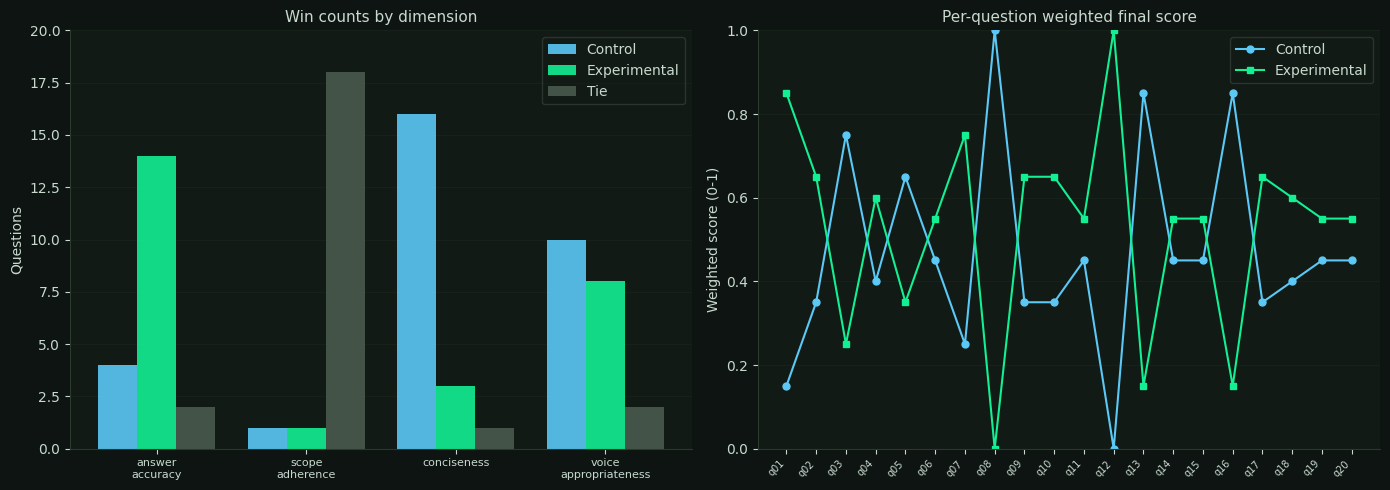

In [15]:
matplotlib.rcParams.update({
    'figure.facecolor': '#0d1411', 'axes.facecolor': '#111a14',
    'text.color': '#c8d9ce', 'axes.labelcolor': '#c8d9ce',
    'xtick.color': '#c8d9ce', 'ytick.color': '#c8d9ce',
    'axes.edgecolor': '#2a3a2e', 'grid.color': '#1e2e22',
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: win counts by dimension
ax = axes[0]
dim_labels = [d.replace('_', '\n') for d in DIMS]
x, w = np.arange(len(DIMS)), 0.26
ctrl_wins = [sum(1 for qid in judged_df['q_id'] if verdicts_by_qid[qid].get(d) == 'control')      for d in DIMS]
exp_wins  = [sum(1 for qid in judged_df['q_id'] if verdicts_by_qid[qid].get(d) == 'experimental') for d in DIMS]
ties      = [sum(1 for qid in judged_df['q_id'] if verdicts_by_qid[qid].get(d) == 'tie')          for d in DIMS]
ax.bar(x - w, ctrl_wins, w, label='Control',      color='#5bc8f5', alpha=0.9)
ax.bar(x,     exp_wins,  w, label='Experimental', color='#13ef93', alpha=0.9)
ax.bar(x + w, ties,      w, label='Tie',          color='#4a5a4e', alpha=0.9)
ax.set_xticks(x); ax.set_xticklabels(dim_labels, fontsize=8)
ax.set_ylim(0, N_QUESTIONS); ax.set_ylabel('Questions')
ax.set_title('Win counts by dimension', fontsize=11)
ax.legend(framealpha=0.15); ax.yaxis.grid(True, alpha=0.4); ax.set_axisbelow(True)
for s in ['top', 'right']: ax.spines[s].set_visible(False)

# Right: per-question weighted final score
ax2 = axes[1]
xi  = np.arange(len(judged_df))
ax2.plot(xi, judged_df['control_final'],      'o-', color='#5bc8f5', label='Control',      lw=1.5, ms=5)
ax2.plot(xi, judged_df['experimental_final'], 's-', color='#13ef93', label='Experimental', lw=1.5, ms=5)
ax2.set_xticks(xi); ax2.set_xticklabels(judged_df['q_id'], rotation=45, ha='right', fontsize=7)
ax2.set_ylim(0, 1); ax2.set_ylabel('Weighted score (0-1)')
ax2.set_title('Per-question weighted final score', fontsize=11)
ax2.legend(framealpha=0.15); ax2.yaxis.grid(True, alpha=0.4); ax2.set_axisbelow(True)
for s in ['top', 'right']: ax2.spines[s].set_visible(False)

plt.tight_layout()
plt.savefig(EVAL_DIR / 'results_chart.png', dpi=150, bbox_inches='tight')
plt.show()